<a href="https://colab.research.google.com/github/Vitor-neia/An-lise-Explorat-ria-de-a-es-da-B3-com-foco-no-setor-Banc-rio/blob/b3/analise_bancos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!pip install adjustText
from adjustText import adjust_text

In [2]:
Base_Dados = pd.read_csv('/content/statusinvest-busca-avancada (1).csv', sep=';', decimal=',')
Base_Dados.head(10)

,TICKER,PRECO,DY,P/L,P/VP,P/ATIVOS,MARGEM BRUTA,MARGEM EBIT,MARG. LIQUIDA,P/EBIT,...,PATRIMONIO / ATIVOS,PASSIVOS / ATIVOS,GIRO ATIVOS,CAGR RECEITAS 5 ANOS,CAGR LUCROS 5 ANOS,LIQUIDEZ MEDIA DIARIA,VPA,LPA,PEG Ratio,VALOR DE MERCADO
0,ABCB4,25.81,10.14,6.51,0.94,0.10,20.09,11.47,9.40,5.34,...,0.11,0.89,0.17,35.11,14.28,"17.243.043,47",27.39,3.96,0.20,"6.314.593.479,17"
1,BAZA3,80.01,10.01,4.18,0.62,0.07,20.35,18.56,17.66,3.98,...,0.12,0.88,0.10,26.63,31.27,"450.775,95",129.92,19.15,-0.24,"4.485.225.783,15"
2,BBAS3,24.28,4.87,8.75,0.76,0.05,32.84,1.87,5.20,24.36,...,0.07,0.93,0.12,17.31,-0.60,"597.731.660,37",31.78,2.78,-0.17,"139.144.650.491,20"
3,BBDC4,20.79,6.94,10.20,1.25,0.10,30.41,7.36,8.56,11.86,...,0.08,0.92,0.11,11.40,0.54,"568.140.792,79",16.58,2.04,0.22,"204.720.627.381,60"
4,BEES4,8.25,8.61,8.39,1.17,0.07,29.87,8.53,6.68,6.57,...,0.06,0.94,0.13,17.11,9.69,"44.702,79",7.04,0.98,-0.84,"2.849.121.742,50"
5,BGIP4,35.32,18.44,5.75,0.88,0.06,30.71,11.76,7.75,3.79,...,0.07,0.93,0.13,13.57,9.63,"89.692,89",40.31,6.15,-0.57,"852.340.158,54"
6,BIDI4,3.41,NaN,-234.18,1.06,0.23,50.04,-13.62,-5.22,-89.72,...,0.22,0.78,0.02,5.80,NaN,NaN,3.22,-0.01,0.12,"8.991.139.764,53"
7,BMEB4,65.20,2.84,11.00,3.03,0.22,45.51,8.04,8.24,11.26,...,0.07,0.93,0.24,21.54,41.20,"3.292.537,37",21.53,5.93,-1.43,"5.863.546.872,96"
8,BMGB4,4.92,11.12,7.44,0.64,0.06,39.56,2.79,4.32,11.52,...,0.10,0.90,0.19,20.01,0.44,"5.600.154,53",7.67,0.66,1.03,"2.947.514.406,48"
9,BMIN4,19.71,7.10,11.82,0.66,0.15,14.65,25.00,12.76,6.03,...,0.22,0.78,0.10,24.69,29.30,"4.921,58",29.92,1.67,-5.10,"108.602.078,96"


In [3]:
#   Colunas e Linhas

Base_Dados.shape

(25, 30)

In [4]:
# Informações

Base_Dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   TICKER                  25 non-null     object 
 1   PRECO                   25 non-null     float64
 2   DY                      19 non-null     float64
 3   P/L                     25 non-null     float64
 4   P/VP                    25 non-null     float64
 5   P/ATIVOS                25 non-null     float64
 6   MARGEM BRUTA            24 non-null     float64
 7   MARGEM EBIT             24 non-null     float64
 8   MARG. LIQUIDA           24 non-null     float64
 9   P/EBIT                  25 non-null     float64
 10  EV/EBIT                 25 non-null     float64
 11  DIVIDA LIQUIDA / EBIT   3 non-null      float64
 12  DIV. LIQ. / PATRI.      3 non-null      float64
 13  PSR                     24 non-null     float64
 14  P/CAP. GIRO             23 non-null     floa

In [5]:
# Dados nulos
Base_Dados.isnull().sum()

,0
TICKER,0
PRECO,0
DY,6
P/L,0
P/VP,0
P/ATIVOS,0
MARGEM BRUTA,1
MARGEM EBIT,1
MARG. LIQUIDA,1
P/EBIT,0


In [6]:
# Estatistícas

Base_Dados.describe()

,PRECO,DY,P/L,P/VP,P/ATIVOS,MARGEM BRUTA,MARGEM EBIT,MARG. LIQUIDA,P/EBIT,EV/EBIT,...,ROA,ROIC,PATRIMONIO / ATIVOS,PASSIVOS / ATIVOS,GIRO ATIVOS,CAGR RECEITAS 5 ANOS,CAGR LUCROS 5 ANOS,VPA,LPA,PEG Ratio
count,25.000000,19.000000,25.000000,25.000000,25.000000,24.000000,24.000000,24.000000,25.000000,25.000000,...,25.000000,3.000000,25.00000,25.000000,25.000000,24.000000,22.000000,25.000000,25.000000,25.00000
mean,28.951600,7.600000,14.395600,1.131600,0.164400,34.134583,17.985000,11.965833,26.009200,33.932800,...,1.450400,5.336667,0.16400,0.833600,0.125200,14.999167,5.840455,36.219600,4.711200,-0.14120
std,32.908276,4.187196,90.587317,0.744153,0.253707,20.875998,45.112118,52.897581,115.640152,121.131322,...,3.058327,9.496138,0.22891,0.233432,0.066088,13.262125,19.137286,55.904257,7.950102,1.92724
min,0.000000,0.220000,-234.180000,0.000000,0.000000,-18.910000,-40.190000,-154.600000,-89.720000,-91.210000,...,-5.670000,-0.320000,0.04000,0.010000,0.000000,-32.170000,-43.980000,2.310000,-2.180000,-5.10000
25%,8.250000,4.990000,4.430000,0.660000,0.060000,22.732500,2.560000,5.380000,2.760000,2.760000,...,0.820000,-0.145000,0.07000,0.880000,0.100000,11.242500,-3.817500,7.040000,0.660000,-0.24000
50%,17.810000,6.940000,8.390000,0.880000,0.100000,33.825000,9.315000,7.425000,6.030000,6.890000,...,1.020000,0.030000,0.10000,0.900000,0.130000,15.135000,9.345000,16.580000,1.660000,0.00000
75%,35.320000,10.075000,11.000000,1.250000,0.160000,45.575000,14.157500,11.635000,11.140000,11.030000,...,1.580000,8.165000,0.12000,0.930000,0.170000,23.790000,15.547500,29.920000,3.970000,0.20000
max,117.420000,18.440000,379.070000,3.030000,1.320000,100.000000,213.640000,193.630000,567.540000,567.540000,...,14.030000,16.300000,0.99000,0.960000,0.240000,35.110000,41.200000,233.360000,28.600000,6.44000


/tmp/ipython-input-991464254.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  grafico = sns.barplot(data=df_top10, x='VALOR_BILHOES', y='TICKER' , palette='viridis')


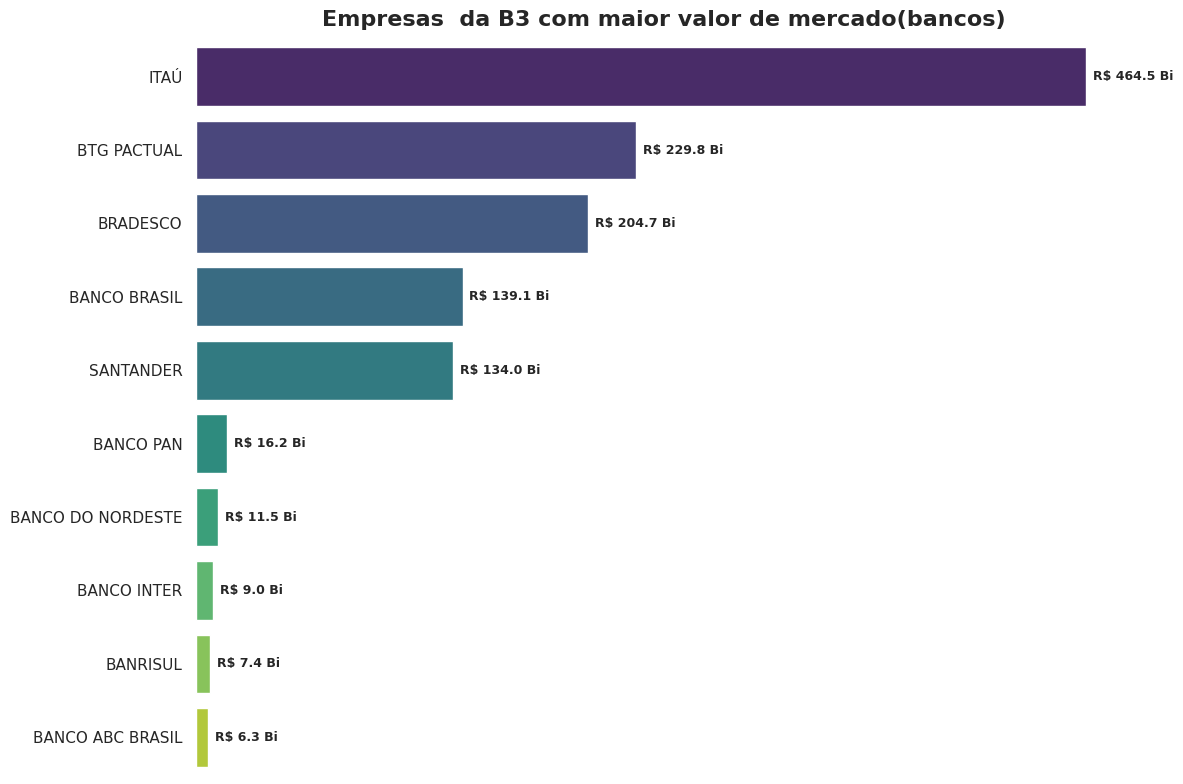

In [20]:
df_plot = Base_Dados.copy()

# Convertendo VALOR DE MERCADO
df_plot[' VALOR DE MERCADO'] = df_plot[' VALOR DE MERCADO'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)


# Criando coluna VALOR BILHOES
df_plot['VALOR_BILHOES'] = df_plot[' VALOR DE MERCADO'] / 1_000_000_000

# RETIRANDO ITSA4, controla o itaú
df_top10 = df_plot[df_plot['TICKER'] != 'ITAUSA'].sort_values(by='VALOR_BILHOES', ascending=False).head(10)

inter_rename = {'BIDI4' : 'BANCO INTER'
}

df_top10 ['TICKER'] = df_top10 ['TICKER'].map(inter_rename).fillna(df_top10['TICKER'])


plt.figure(figsize=(12, 8))
sns.set_theme(style="white")
grafico = sns.barplot(data=df_top10, x='VALOR_BILHOES', y='TICKER' , palette='viridis')

# Adicionar os valores na barra

formato = 'R$ %.1f Bi'
estilo = {'padding': 5, 'fontweight': 'bold', 'fontsize': 9}

# Aplicando
for c in grafico.containers:
    grafico.bar_label(c, fmt=formato, **estilo)

# Ajustes de eixos e titulos
plt.title('Empresas  da B3 com maior valor de mercado(bancos)' , fontsize=16, fontweight='bold', pad=10, loc='center')

# REMOVENDO O EIXO E A MOLDURA DE BAIXO
plt.xlabel('') # Remove o texto do eixo X
plt.xticks([]) # Remove os números do eixo X
plt.ylabel('') # Remove o texto "Empresas" para limpar o visual
sns.despine(bottom=True, left=True) # Apaga a linha de baixo e da esquerda
plt.tight_layout()
plt.show()

/tmp/ipython-input-3805786109.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_10_dy, x='DY', y='TICKER', palette='viridis')


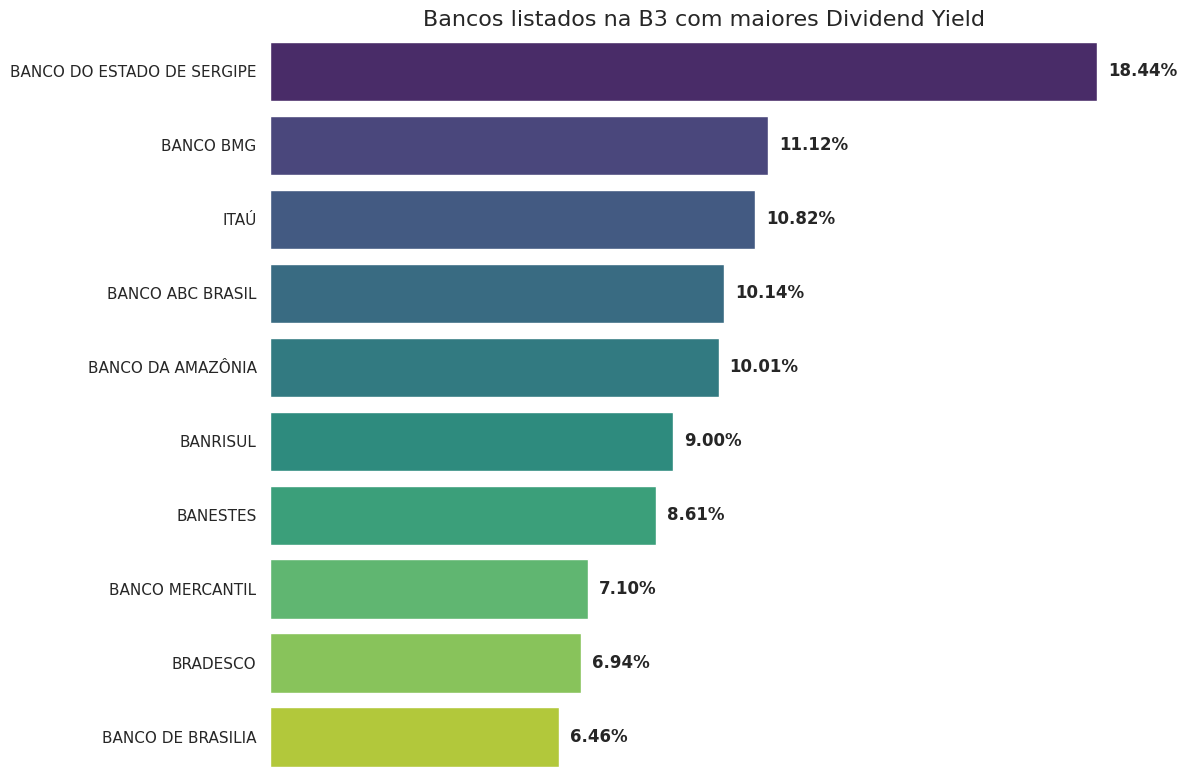

In [8]:

# TOP 10 DY POR BANCOS
top_10_dy = Base_Dados[Base_Dados['TICKER'] != 'ITSA4'].sort_values('DY', ascending=False).head(10).copy()

nomes_bancos_dy = {
    'BGIP4' : 'BANCO DO ESTADO DE SERGIPE' ,
    'BMGB4' : 'BANCO BMG' ,
    'ITUB4' : 'ITAÚ' ,
    'BSLI4' : 'BANCO DE BRASILIA' ,
    'BAZA3' : 'BANCO DA AMAZÔNIA' ,
    'BEES4' : 'BANESTES' ,
    'BMIN4' : 'BANCO MERCANTIL' ,
    'BBDC4' : 'BRADESCO' ,
    'BRSR6' : 'BANRISUL' ,
    'ABCB4' : 'BANCO ABC BRASIL'
}

top_10_dy['TICKER'] = top_10_dy['TICKER'].map(nomes_bancos_dy).fillna(top_10_dy['TICKER'])

# 2. Configuração do Gráfico
plt.figure(figsize=(12, 8))
sns.set_theme(style="white")
ax = sns.barplot(data=top_10_dy, x='DY', y='TICKER', palette='viridis')

# Porcentagem nas barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', padding=8, fontsize=12, fontweight='bold')
plt.title('Bancos listados na B3 com maiores Dividend Yield' , fontsize=16)
plt.xlabel('') # Remove o texto do eixo X
plt.xticks([]) # Remove os números do eixo X
plt.ylabel('') # Remove o texto "Empresas" para limpar o visual
sns.despine(bottom=True, left=True) # Apaga a linha de baixo e da esquerda
plt.tight_layout()
plt.show()

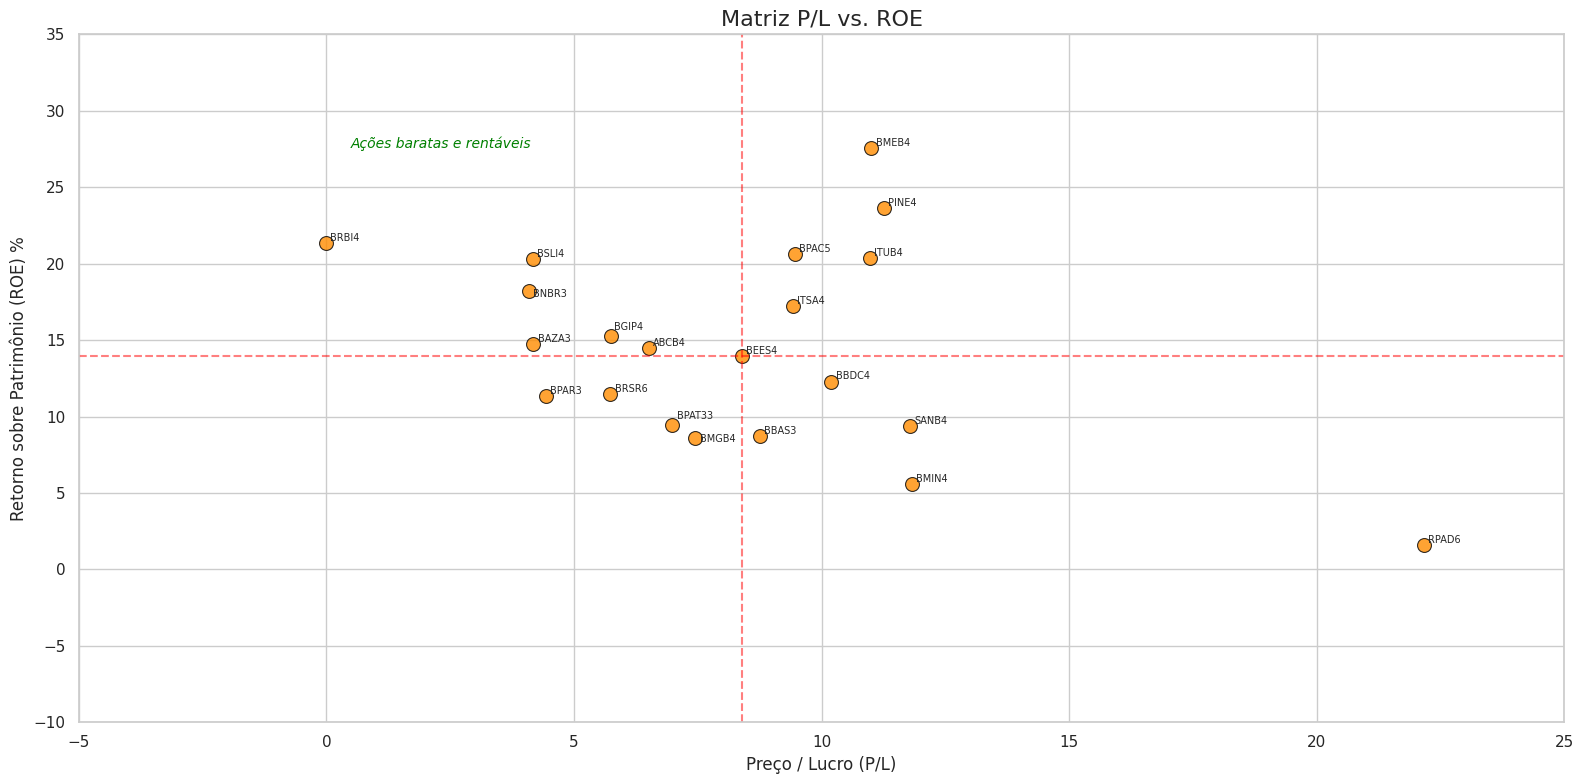

In [9]:
# Filtrando colunas PL e ROE
plt_Base_Dados = Base_Dados.dropna(subset=['P/L' , 'ROE'])

# Filtrando outliners
Base_Dados_plt = Base_Dados[(Base_Dados['P/L'] > -20) & (Base_Dados['P/L'] < 50)].dropna(subset=['P/L', 'ROE'])


# Gráfico
plt.figure(figsize=(16, 8))
sns.set_style('whitegrid')
plt.xlim(-5, 25) #ignorou banco pan
plt.ylim(-10, 35)

# Gráfico de dispersão
sns.scatterplot(data=Base_Dados_plt, x='P/L', y='ROE', s=100, color='darkorange' , edgecolor='black' , alpha=0.8)


# Linhas da média, referência
plt.axvline(x=Base_Dados_plt['P/L'].median(), color='red', linestyle='--', alpha=0.5)
plt.axhline(y=Base_Dados_plt['ROE'].median(), color='red', linestyle='--', alpha=0.5)

# o Grafico ficou amontoado, usei esse cod, para ajustar com a biblioteca adjust text
texts = []
for i, txt in enumerate(Base_Dados_plt['TICKER']):
    if -5 < Base_Dados_plt['P/L'].iloc[i] < 25 and -10 < Base_Dados_plt['ROE'].iloc[i] < 35:
        texts.append(plt.text(Base_Dados_plt['P/L'].iloc[i], Base_Dados_plt['ROE'].iloc[i], txt, fontsize=7))

# Ajustando  os textos
adjust_text(texts,
            arrowprops=dict(arrowstyle='->', color='gray', lw=0.5), # Adiciona setinhas discretas
            expand_points=(1.5, 1.5),
            force_points=0.1)


plt.title('Matriz P/L vs. ROE', fontsize=16)
plt.xlabel('Preço / Lucro (P/L)', fontsize=12)
plt.ylabel('Retorno sobre Patrimônio (ROE) %', fontsize=12)
plt.text(0.5, df_plot['ROE'].max(), 'Ações baratas e rentáveis', color='green', fontsize=10, style='italic')
plt.tight_layout()
plt.show()

/tmp/ipython-input-318235454.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  grafico = sns.barplot(data=Base_Dados_graham, x='TICKER', y='Margem', palette=cores)


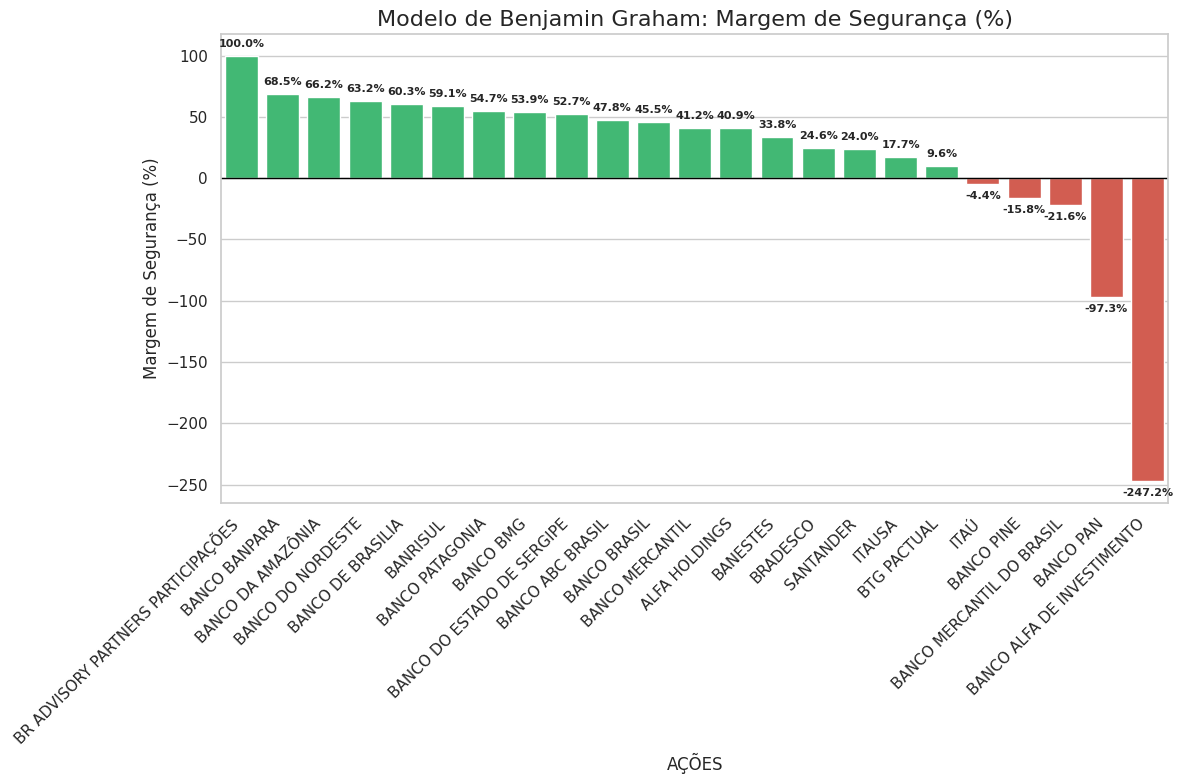

In [10]:
nomes_empresas = {
    'BGIP4' : 'BANCO DO ESTADO DE SERGIPE' ,
    'BMGB4' : 'BANCO BMG' ,
    'ITUB4' : 'ITAÚ' ,
    'BSLI4' : 'BANCO DE BRASILIA' ,
    'BAZA3' : 'BANCO DA AMAZÔNIA' ,
    'BEES4' : 'BANESTES' ,
    'BMIN4' : 'BANCO MERCANTIL' ,
    'BBDC4' : 'BRADESCO' ,
    'BRSR6' : 'BANRISUL' ,
    'ABCB4' : 'BANCO ABC BRASIL' ,
    'SANB4' : 'SANTANDER' ,
    'BPAT33': 'BANCO PATAGONIA' ,
    'BNBR3' : 'BANCO DO NORDESTE' ,
    'BRBI4' : 'BR ADVISORY PARTNERS PARTICIPAÇÕES' ,
    'BPAR3' : 'BANCO BANPARA' ,
    'RPAD6' : 'ALFA HOLDINGS' ,
    'ITSA4' : 'ITAUSA' ,
    'BPAC5' : 'BTG PACTUAL' ,
    'PINE4' : 'BANCO PINE' ,
    'BMEB4' : 'BANCO MERCANTIL DO BRASIL' ,
    'BPAN4' : 'BANCO PAN' ,
    'BRIV4' : 'BANCO ALFA DE INVESTIMENTO' ,
    'BBAS3' : 'BANCO BRASIL'
}
# rENOMEEI EMPRESAS
Base_Dados['TICKER'] = Base_Dados['TICKER'].replace(nomes_empresas)

Base_Dados_graham = Base_Dados[(Base_Dados[' LPA'] > 0) & (Base_Dados[' VPA'] > 0)].copy()
Base_Dados_graham['VI'] = np.sqrt(22.5 * Base_Dados_graham[' LPA'] * Base_Dados_graham[' VPA'])
Base_Dados_graham['Margem'] = ((Base_Dados_graham['VI'] - Base_Dados_graham['PRECO']) / Base_Dados_graham['VI']) * 100
Base_Dados_graham = Base_Dados_graham.sort_values(by='Margem', ascending=False)
# 3. Criar o Gráfico
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Cores: verde para margem positiva, vermelho para negativa
cores = ['#2ecc71' if x > 0 else '#e74c3c' for x in Base_Dados_graham['Margem']]

grafico = sns.barplot(data=Base_Dados_graham, x='TICKER', y='Margem', palette=cores)

# Adicionar os valores na barra
formato = '%.1f%%'
estilo = {'padding': 5, 'fontweight': 'bold', 'fontsize': 8}

# Aplicando
for c in grafico.containers:
    grafico.bar_label(c, fmt=formato, **estilo)


plt.axhline(0, color='black', linewidth=1)
plt.title('Modelo de Benjamin Graham: Margem de Segurança (%)', fontsize=16)
plt.xlabel('AÇÕES')
plt.ylabel('Margem de Segurança (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipython-input-3352218319.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  grafico = sns.barplot(data=df_top10, x='VALOR_BILHOES', y='TICKER' , palette='viridis' , ax=axes[0, 0])
/tmp/ipython-input-3352218319.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_10_dy, x='DY', y='TICKER', palette='viridis' , ax=axes[0,1])
/tmp/ipython-input-3352218319.py:171: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  grafico = sns.barplot(data=Base_Dados_graham, x='Margem', y='TICKER', palette=cores, ax=axes[1,0])


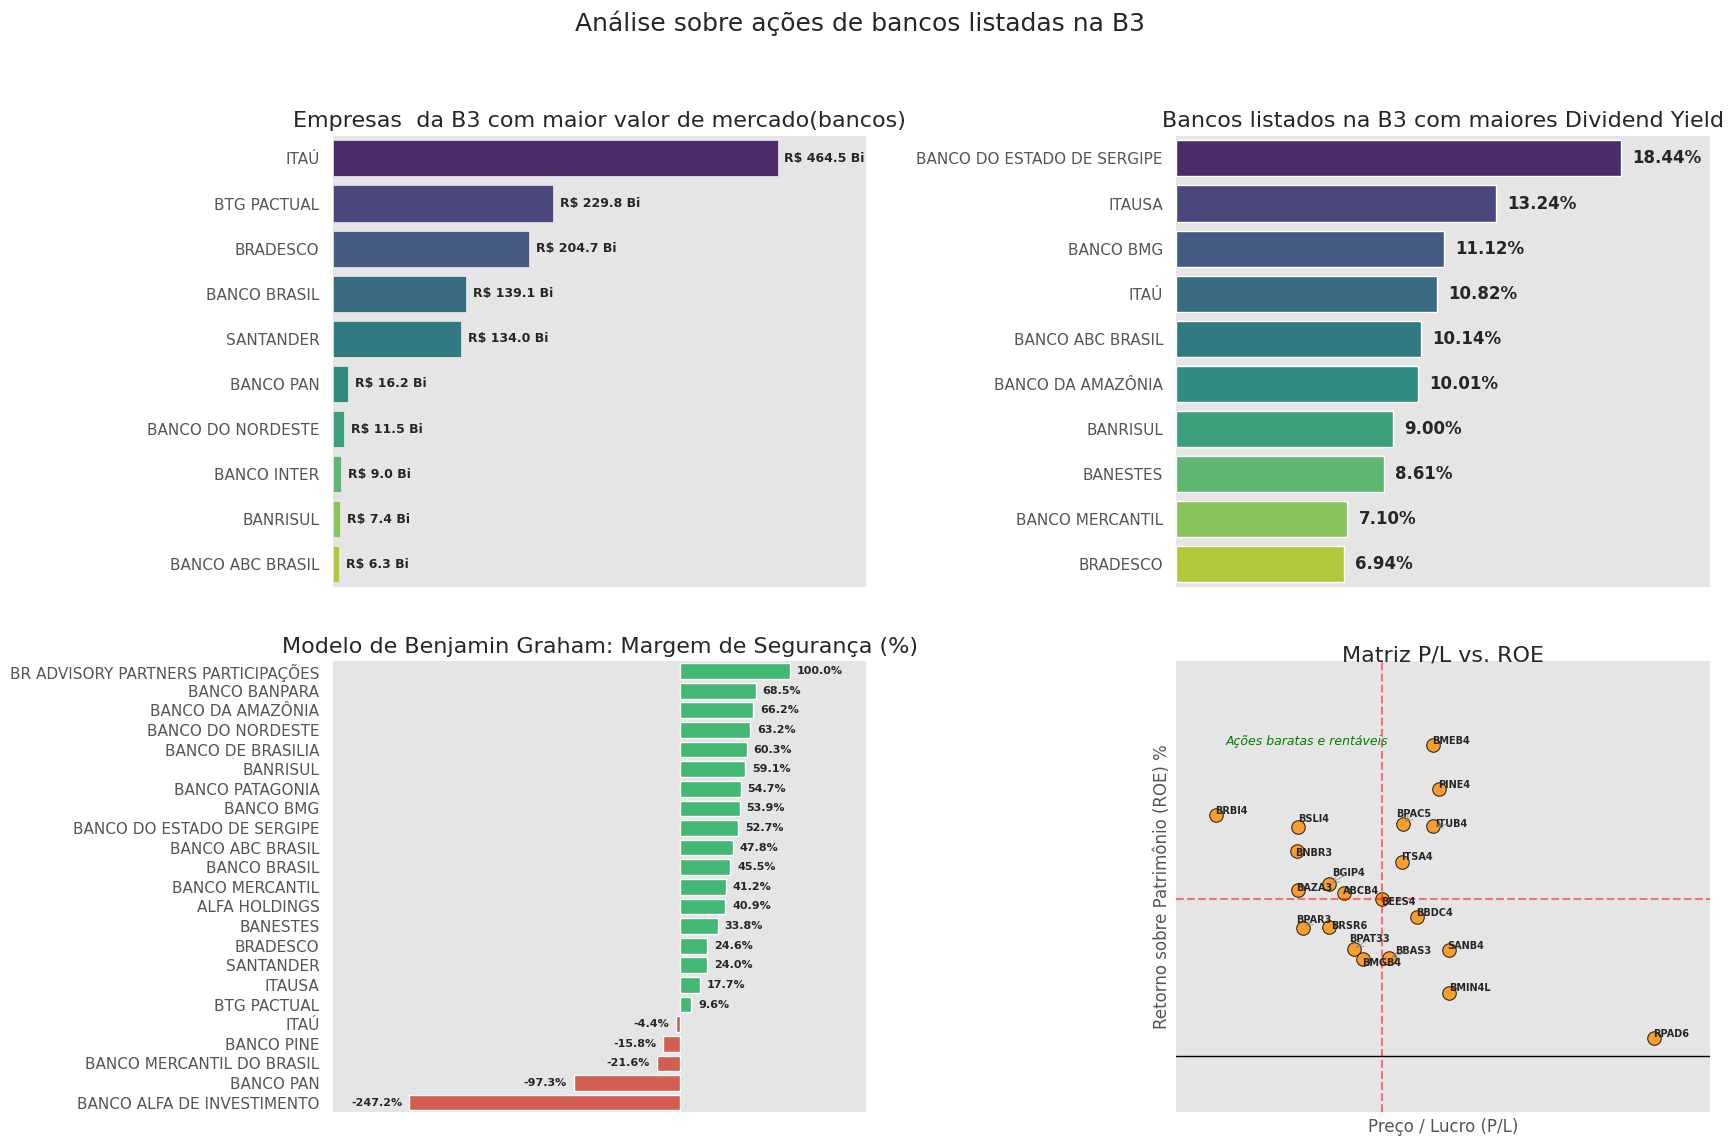

In [21]:
# Estilo
plt.style.use('ggplot')

# Criando figura
fig, axes = plt.subplots(2, 2, figsize=(18,12))

fig.suptitle('Análise sobre ações de bancos listadas na B3', fontsize=18, y=0.98)

df_plot = Base_Dados.copy()

# Convertendo VALOR DE MERCADO
df_plot[' VALOR DE MERCADO'] = df_plot[' VALOR DE MERCADO'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)


# Criando coluna VALOR BILHOES
df_plot['VALOR_BILHOES'] = df_plot[' VALOR DE MERCADO'] / 1_000_000_000

# RETIRANDO ITSA4, controla o itaú
df_top10 = df_plot[df_plot['TICKER'] != 'ITAUSA'].sort_values(by='VALOR_BILHOES', ascending=False).head(10)

inter_rename = {'BIDI4' : 'BANCO INTER'
}

df_top10 ['TICKER'] = df_top10 ['TICKER'].map(inter_rename).fillna(df_top10['TICKER'])



grafico = sns.barplot(data=df_top10, x='VALOR_BILHOES', y='TICKER' , palette='viridis' , ax=axes[0, 0])
axes[0, 0].set_title('Empresas  da B3 com maior valor de mercado(bancos)', fontsize=16)
axes[0, 0].set_xlabel('')
axes[0, 0].margins(x=0.2)
axes[0, 0].set_xticks([])
axes[0, 0].set_ylabel('', fontsize=12)

# Adicionar os valores na barra

formato = 'R$ %.1f Bi'
estilo = {'padding': 5, 'fontweight': 'bold', 'fontsize': 9}

# Aplicando
for c in grafico.containers:
    grafico.bar_label(c, fmt=formato, **estilo)





sns.despine(bottom=True, left=True) # Apaga a linha de baixo e da esquerda
plt.tight_layout(pad=3.0)

# Gráfico 2
# TOP 10 DY POR BANCOS
top_10_dy = Base_Dados[Base_Dados['TICKER'] != 'ITSA4'].sort_values('DY', ascending=False).head(10).copy()

nomes_bancos_dy = {
    'BGIP4' : 'BANCO DO ESTADO DE SERGIPE' ,
    'BMGB4' : 'BANCO BMG' ,
    'ITUB4' : 'ITAÚ' ,
    'BSLI4' : 'BANCO DE BRASILIA' ,
    'BAZA3' : 'BANCO DA AMAZÔNIA' ,
    'BEES4' : 'BANESTES' ,
    'BMIN4' : 'BANCO MERCANTIL' ,
    'BBDC4' : 'BRADESCO' ,
    'BRSR6' : 'BANRISUL' ,
    'ABCB4' : 'BANCO ABC BRASIL'
}

top_10_dy['TICKER'] = top_10_dy['TICKER'].map(nomes_bancos_dy).fillna(top_10_dy['TICKER'])

# 2. Configuração do Gráfico
sns.set_theme(style="white")
ax = sns.barplot(data=top_10_dy, x='DY', y='TICKER', palette='viridis' , ax=axes[0,1])
axes[0, 1].set_title('Bancos listados na B3 com maiores Dividend Yield', fontsize=16)
axes[0, 1].set_xlabel('')
axes[0, 1].margins(x=0.2)
axes[0, 1].set_ylabel('')
axes[0, 1].set_xticks([])

# Porcentagem nas barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', padding=8, fontsize=12, fontweight='bold')

sns.despine(bottom=True, left=True) # Apaga a linha de baixo e da esquerda
plt.tight_layout(pad=3.0)

# Gráfico 4


# Filtrando colunas PL e ROE
plt_Base_Dados = Base_Dados.dropna(subset=['P/L' , 'ROE'])

# Filtrando outliners
Base_Dados_plt = Base_Dados[(Base_Dados['P/L'] > -20) & (Base_Dados['P/L'] < 50)].dropna(subset=['P/L', 'ROE'])
tickers_originais = {
   'BANCO DO ESTADO DE SERGIPE' : 'BGIP4' ,
  'BANCO BMG': 'BMGB4' ,
   'ITAÚ'  : 'ITUB4' ,
   'BANCO DE BRASILIA'  : 'BSLI4' ,
   'BANCO DA AMAZÔNIA'  : 'BAZA3' ,
   'BANESTES'  : 'BEES4' ,
   'BANCO MERCANTIL'  : 'BMIN4L' ,
   'BRADESCO'  : 'BBDC4' ,
   'BANRISUL' : 'BRSR6' ,
   'BANCO ABC BRASIL' : 'ABCB4' ,
   'SANTANDER'  : 'SANB4' ,
   'BANCO PATAGONIA' : 'BPAT33' ,
   'BANCO DO NORDESTE'  : 'BNBR3' ,
   'BR ADVISORY PARTNERS PARTICIPAÇÕES'  : 'BRBI4' ,
   'BANCO BANPARA'  : 'BPAR3' ,
   'ALFA HOLDINGS'  : 'RPAD6' ,
   'ITAUSA'  : 'ITSA4' ,
   'BTG PACTUAL' : 'BPAC5' ,
   'BANCO PINE' : 'PINE4' ,
   'BANCO MERCANTIL DO BRASIL' : 'BMEB4' ,
   'BANCO PAN'  : 'BPAN4' ,
   'BANCO ALFA DE INVESTIMENTO' : 'BRIV4' ,
   'BANCO BRASIL': 'BBAS3'
}
# rENOMEEI EMPRESAS
Base_Dados_plt['TICKER'] = Base_Dados_plt['TICKER'].replace(tickers_originais)

# Gráfico
axes[1,1].set_xlim(-2, 25) #ignorou banco pan
axes[1,1].set_ylim(-5, 35)

# Gráfico de dispersão
sns.scatterplot(data=Base_Dados_plt, x='P/L', y='ROE', s=95, color='darkorange' , edgecolor='black' , alpha=0.8, ax=axes[1, 1])
axes[1,1].set_title('Matriz P/L vs. ROE', fontsize=16, y=0.98)
axes[1,1].set_xlabel('Preço / Lucro (P/L)', fontsize=12)
axes[1,1].margins(x=0.2)
axes[1,1].set_ylabel('Retorno sobre Patrimônio (ROE) %', fontsize=12)
axes[1,1].set_yticks([])
axes[1,1].set_xticks([])
axes[1,1].text(0.5, df_plot['ROE'].max(), 'Ações baratas e rentáveis', color='green', fontsize=9, style='italic')
# Linhas da média, referência
axes[1,1].axvline(x=Base_Dados_plt['P/L'].median(), color='red', linestyle='--', alpha=0.5)
axes[1,1].axhline(y=Base_Dados_plt['ROE'].median(), color='red', linestyle='--', alpha=0.5)

# o Grafico ficou amontoado, usei esse cod, para ajustar com a biblioteca adjust text
texts = []
for i in range(len(Base_Dados_plt)):
    x = Base_Dados_plt['P/L'].iloc[i]
    y = Base_Dados_plt['ROE'].iloc[i]
    txt = Base_Dados_plt['TICKER'].iloc[i]
for i, txt in enumerate(Base_Dados_plt['TICKER']):
    if -5 < Base_Dados_plt['P/L'].iloc[i] < 25 and -10 < Base_Dados_plt['ROE'].iloc[i] < 35:
     texts.append(axes[1,1].text(Base_Dados_plt['P/L'].iloc[i], Base_Dados_plt['ROE'].iloc[i], txt, fontsize=7 , fontweight='bold'))

# Ajustando  os textos
adjust_text(texts, ax=axes[1,1],
            arrowprops=dict(arrowstyle='->', color='gray', lw=0.5), # Adiciona setas
            expand_points=(1.5, 1.5),
            force_points=0.1)

plt.tight_layout(pad=3.0)

# Gráfico 3

Base_Dados_graham = Base_Dados[(Base_Dados[' LPA'] > 0) & (Base_Dados[' VPA'] > 0)].copy()
Base_Dados_graham['VI'] = np.sqrt(22.5 * Base_Dados_graham[' LPA'] * Base_Dados_graham[' VPA'])
Base_Dados_graham['Margem'] = ((Base_Dados_graham['VI'] - Base_Dados_graham['PRECO']) / Base_Dados_graham['VI']) * 100
Base_Dados_graham = Base_Dados_graham.sort_values(by='Margem', ascending=False)


# 3. Criar o Gráfico
sns.set_style("whitegrid")

# Cores: verde para margem positiva, vermelho para negativa
cores = ['#2ecc71' if x > 0 else '#e74c3c' for x in Base_Dados_graham['Margem']]

grafico = sns.barplot(data=Base_Dados_graham, x='Margem', y='TICKER', palette=cores, ax=axes[1,0])
axes[1,0].set_title('Modelo de Benjamin Graham: Margem de Segurança (%)', fontsize=16)
axes[1,0].set_xlabel('')
axes[1,0].margins(x=0.2)
axes[1,0].set_ylabel('')
axes[1,0].set_xticks([])
# Adicionar os valores na barra
formato = '%.1f%%'
estilo = {'padding': 5, 'fontweight': 'bold', 'fontsize': 8}

# Aplicando
for c in grafico.containers:
    grafico.bar_label(c, fmt=formato, **estilo)


plt.axhline(0, color='black', linewidth=1)
plt.tight_layout(pad=3.0)
plt.show()




